In [1]:
import pandas as pd
import numpy as np
import pyarrow.parquet as pq

from itertools import groupby
import statistics

import ipywidgets as widgets
import matplotlib.pyplot as plt


In [2]:
TRAIN_PATH = "../raw_data/train.parquet"

In [3]:
pf = pq.ParquetFile(TRAIN_PATH)
columns = pf.schema.names
num_rows = pf.metadata.num_rows

print("columns: ", columns)
print("number of rows: ", num_rows)
print("measurements pro minute: ", num_rows / 14 / 365 / 24 / 60)

columns:  ['id', 'channel_1', 'channel_10', 'channel_11', 'channel_12', 'channel_13', 'channel_14', 'channel_15', 'channel_16', 'channel_17', 'channel_18', 'channel_19', 'channel_2', 'channel_20', 'channel_21', 'channel_22', 'channel_23', 'channel_24', 'channel_25', 'channel_26', 'channel_27', 'channel_28', 'channel_29', 'channel_3', 'channel_30', 'channel_31', 'channel_32', 'channel_33', 'channel_34', 'channel_35', 'channel_36', 'channel_37', 'channel_38', 'channel_39', 'channel_4', 'channel_40', 'channel_41', 'channel_42', 'channel_43', 'channel_44', 'channel_45', 'channel_46', 'channel_47', 'channel_48', 'channel_49', 'channel_5', 'channel_50', 'channel_51', 'channel_52', 'channel_53', 'channel_54', 'channel_55', 'channel_56', 'channel_57', 'channel_58', 'channel_59', 'channel_6', 'channel_60', 'channel_61', 'channel_62', 'channel_63', 'channel_64', 'channel_65', 'channel_66', 'channel_67', 'channel_68', 'channel_69', 'channel_7', 'channel_70', 'channel_71', 'channel_72', 'channel_7

In [4]:
stats = []

for col_name in columns[1:-1]:

  column = pq.read_table(TRAIN_PATH, columns=[col_name])
  column = column.column(col_name).to_pandas()

  stats.append({
        "column": col_name,
        "mean": column.mean(),
        "std": column.std(),
        "min": column.min(),
        "max": column.max(),
        "nunique": column.nunique()
    })

with pd.option_context('display.max_rows', None):
    display(pd.DataFrame(stats).set_index("column"))


,mean,std,min,max,nunique
column,,,,,
channel_1,1.380301e-01,4.428727e-03,0.092172,0.433187,8892
channel_10,6.403504e-09,1.492817e-06,0.000000,0.000424,110
channel_11,4.395080e-10,2.467632e-07,0.000000,0.000422,61
channel_12,2.557318e-01,5.158953e-02,0.122595,0.996771,229
channel_13,3.094885e-01,5.081466e-02,0.172124,0.991929,205
channel_14,2.720448e-01,9.578262e-02,0.078451,0.971057,534
channel_15,1.210223e-01,6.525146e-02,0.001287,0.541334,388
channel_16,7.610638e-01,7.655781e-02,0.007355,0.914091,485
channel_17,2.927625e-01,5.072071e-02,0.142207,0.984396,242


In [5]:
anomaly = pq.read_table(TRAIN_PATH, columns=["is_anomaly"])
anomaly = anomaly.column("is_anomaly").to_pandas()

shortest anomaly:  1
median anomaly:  601.5
longest anomaly:  116061


(array([147.,  13.,  20.,   7.,   1.,   1.,   0.,   0.,   0.,   1.]),
 array([1.00000e+00, 1.16070e+04, 2.32130e+04, 3.48190e+04, 4.64250e+04,
        5.80310e+04, 6.96370e+04, 8.12430e+04, 9.28490e+04, 1.04455e+05,
        1.16061e+05]),
 <BarContainer object of 10 artists>)

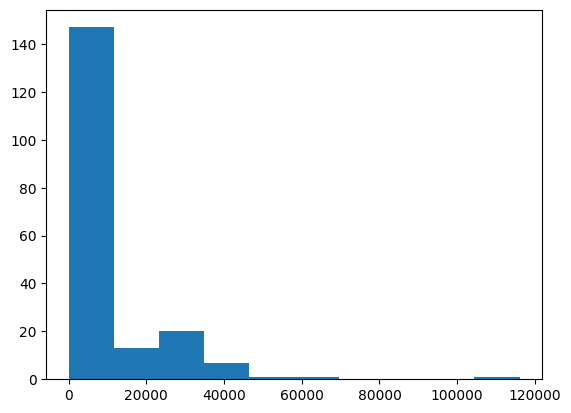

In [6]:
lengths = [len(list(g)) for k, g in groupby(anomaly) if k == 1]

print('shortest anomaly: ', min(lengths))
print('median anomaly: ', statistics.median(lengths))
print('longest anomaly: ', max(lengths))
plt.hist(lengths)

In [7]:
def plot_column(col, width, start):

    column = pq.read_table(TRAIN_PATH, columns=[col])
    column = column.column(col).to_pandas()

    r = range(start, min(num_rows, start+width))
    #lims = (column.min(), column.max())

    mask = anomaly.iloc[r] == 1

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].plot(r, column.iloc[r])
    axes[0].scatter(np.array(r)[mask], column.iloc[r][mask], color='red', s=10)
    #axes[0].set_ylim(lims)
    axes[1].plot(r, column.iloc[r].rolling(window=251, center=True).median())
    #axes[1].set_ylim(lims)
    axes[2].hist(column, bins=10)


In [8]:
widgets.interact(
    plot_column,
    col=widgets.Dropdown(options=columns[1:-1], description="Column"),
    width=widgets.IntSlider(min=100, max=1000000, step=100, value=500, description="Width"),
    start=widgets.IntSlider(min=0, max=num_rows-1, step=1000, description="Start"))

interactive(children=(Dropdown(description='Column', options=('channel_1', 'channel_10', 'channel_11', 'channe…

<function __main__.plot_column(col, width, start)>

In [ ]:
binary_features = ['telecommand_244', 
                   'telecommand_350', 
                   'telecommand_351', 
                   'telecommand_352',
                   'telecommand_353',
                   'telecommand_354',
                   'telecommand_36',
                   'telecommand_376',
                   'telecommand_38',
                   'telecommand_39',
                   'telecommand_40']